# Monai_train_val_test — evaluation / inference only

This notebook **evaluates** the released DenseNet169 cell-type classifier on the
held-out **test** split of a train / val / test (70/10/20) partition and reproduces
the reported numbers. It does **not** train: the training image data is not
distributed, so all training code (training loop, optimizer/loss,
ImageNet-pretrained init, and the model-save steps) has been removed.

To run it you need, for each channel you evaluate:
- the released weights `<MODEL_ROOT>/<CHANNEL>_<MAX_EPOCHS>epochs_model.pth`, and
- the test crops `<DATA_ROOT>/<CHANNEL>/test/<folder_id>/*.tiff`.

See `README_Monai_train_val_test.md` for how to obtain both.

In [ ]:
import os
import pprint
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from monai.config import print_config
from monai.data import Dataset, DataLoader
from monai.networks.nets import DenseNet169
from monai.transforms import (
    Compose,
    ConcatItemsd,
    EnsureChannelFirstd,
    LoadImaged,
    ScaleIntensityRangePercentilesd,
)
from monai.utils import set_determinism

print_config()

## Configuration

All input/output locations are defined in the single **Configuration** cell below.
Nothing else in this notebook contains a hard-coded path.

Edit the defaults in that cell, or override any of them **without touching the
notebook** by exporting the matching environment variable before launch, e.g.

```bash
QUAC_DATA_ROOT=/path/to/dataset QUAC_MODEL_ROOT=/path/to/models jupyter lab
```

Expected on-disk layout for evaluation (see `README_Monai_train_val_test.md`):

```
<QUAC_DATA_ROOT>/<CHANNEL>/test/<folder_id>/*.tiff        # test crops only
<QUAC_MODEL_ROOT>/<CHANNEL>_<MAX_EPOCHS>epochs_model.pth  # released weights
```


In [ ]:
# ============================================================
#  Configuration -- the single source of truth for all paths.
#  Override any value via an environment variable of the same
#  name, or just edit the default on the right-hand side.
# ============================================================
import os

# Nuclear-marker channel to evaluate ("H3K4me1", "DAPI", ...).
CHANNEL     = os.environ.get("QUAC_CHANNEL", "H3K4me1")

# Root holding the per-channel image datasets. Only the test/ split is needed:
#   <DATA_ROOT>/<CHANNEL>/test/<folder_id>/*.tiff
DATA_ROOT   = os.environ.get("QUAC_DATA_ROOT", "./QUAC_8_classes")

# Folder with the released DenseNet169 weights (see README for how to obtain them).
MODEL_ROOT  = os.environ.get("QUAC_MODEL_ROOT", "./QUAC_model/eight_classes_model")

# Where reports, CSVs and figures are written.
OUTPUT_ROOT = os.environ.get("QUAC_OUTPUT_ROOT", "./QUAC_8_classes")

# Epoch count baked into the released weight filenames (e.g. *_50epochs_model.pth).
MAX_EPOCHS  = int(os.environ.get("QUAC_MAX_EPOCHS", "50"))

os.makedirs(OUTPUT_ROOT, exist_ok=True)


def channel_dir(channel):
    """Dataset folder for a channel: <DATA_ROOT>/<channel>."""
    return os.path.join(DATA_ROOT, channel)


def model_path(channel):
    """Released state-dict (.pth) path for a channel."""
    return os.path.join(MODEL_ROOT, f"{channel}_{MAX_EPOCHS}epochs_model.pth")


def jit_path(channel):
    """TorchScript (.pt / \"jit\") path for a channel."""
    return os.path.join(MODEL_ROOT, f"{channel}_{MAX_EPOCHS}epochs_jit.pt")


print(f"CHANNEL         = {CHANNEL}")
print(f"DATA_ROOT       = {DATA_ROOT}")
print(f"MODEL_ROOT      = {MODEL_ROOT}")
print(f"OUTPUT_ROOT     = {OUTPUT_ROOT}")
print(f"MAX_EPOCHS      = {MAX_EPOCHS}")

In [2]:
torch.cuda.is_available()

True

In [ ]:
# Define dataset paths (CHANNEL / DATA_ROOT come from the Configuration cell).
# Evaluation uses the held-out test/ split only; classes are auto-detected from it.
base_path = channel_dir(CHANNEL)                 # e.g. ./QUAC_8_classes/H3K4me1
test_dir  = os.path.join(base_path, "test")      # held-out 20% split (70/10/20)

# List all class names (subdirectory names)
classes = sorted(os.listdir(test_dir))
class_map = {c: idx for idx, c in enumerate(classes)}
num_classes = len(classes)

# Encode labels using class_map
def encode_label(path):
    class_name = os.path.basename(os.path.dirname(path))
    return class_map[class_name]

# Build a list of image paths and their corresponding labels
def build_datalist(data_dir):
    datalist = []
    for class_name in os.listdir(data_dir):
        class_dir = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_dir):
            continue
        for image_name in os.listdir(class_dir):
            if image_name.lower() == "thumbs.db":
                continue
            image_path = os.path.join(class_dir, image_name)
            label = encode_label(image_path)
            datalist.append({"image": image_path, "label": label})
    return datalist

test_datalist = build_datalist(test_dir)   # held-out test set

In [ ]:
pp = pprint.PrettyPrinter()
pp.pprint(test_datalist[:3])

In [ ]:
# Human-readable name for each dataset folder id. Modify to your folder--class correspondence;
# any folder not listed here falls back to its folder id, so num_classes and
# class_names are always auto-detected from whatever folders exist under test/.
folder_to_class = {
    "0": "CTX-Glut",
    "5": "CTX-Olig",
    "8": "CTX-GABA",
    "11": "CTX-Astro",
    "13": "ExN Gluta TH",
    "16": "ExN CA1",
    "19": "ExN CA3",
    "22": "ExN cortex layer",
}

# Map folder names -> sequential indices (auto-detected from the test/ folders)
classes = sorted(os.listdir(test_dir))
class_map = {c: idx for idx, c in enumerate(classes)}

# Inverse mapping (index -> readable name); unknown folders keep their id
class_map_inv = {idx: folder_to_class.get(folder_name, folder_name)
                 for folder_name, idx in class_map.items()}

num_classes = len(classes)                        # auto-detected number of classes
class_names = list(class_map_inv.values())

In [11]:
class_names

['CTX-Glut',
 'CTX-Astro',
 'ExN Gluta TH',
 'ExN CA1',
 'ExN CA3',
 'ExN cortex layer',
 'CTX-Olig',
 'CTX-GABA']

In [186]:
# print("Unique labels in train_datalist:", {d["label"] for d in train_datalist})
# print("Labels in this batch:", batch_data["label"].tolist())

In [ ]:
# visualize a few test crops with normalization (sanity check on the inputs)
set_determinism(seed=0)
transforms_visualize = Compose(
    [
        LoadImaged(keys=['image'], reader="PILReader", image_only=True),
        EnsureChannelFirstd(keys=['image']),
        ScaleIntensityRangePercentilesd(
            keys=['image'], lower=1.0, upper=99.0, b_min=0.0, b_max=1.0, clip=True
        ),
    ]
)

batch_size_viz = 6
viz_ds = Dataset(test_datalist, transform=transforms_visualize)
viz_loader = DataLoader(viz_ds, batch_size=batch_size_viz, shuffle=True, num_workers=0)
batch_data = next(iter(viz_loader))

fig, axs = plt.subplots(1, batch_size_viz, figsize=(15,5))
for idx in range(batch_size_viz):
    img = batch_data['image'][idx].squeeze().numpy()  # Remove channel dimension if needed
    axs[idx].imshow(img, cmap="gray")
    axs[idx].axis("off")
    label = int(batch_data['label'][idx])
    label_name = class_map_inv.get(label, f"Unknown ({label})")
    axs[idx].set_title(label_name)
fig.tight_layout()
plt.show()

In [ ]:
# Inference transforms (used for the held-out test evaluation).
keys = ["image"]

transforms_val = Compose(
    [
        LoadImaged(keys=keys, reader="PILReader", image_only=True),
        EnsureChannelFirstd(keys=keys),
        ScaleIntensityRangePercentilesd(
            keys=keys, lower=1.0, upper=99.0, b_min=0.0, b_max=1.0, clip=True
        ),
        ConcatItemsd(keys=keys, name="image", dim=0),
    ]
)

In [ ]:
# Load the released model for CHANNEL and put it in eval mode

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = DenseNet169(
    spatial_dims=2,
    in_channels=1,
    out_channels=num_classes,    # auto-detected number of classes
    pretrained=False             # weights come from the released checkpoint below
)

# Load the released weights for CHANNEL (matches the reported numbers)
model.load_state_dict(torch.load(model_path(CHANNEL),
                                 map_location=device, weights_only=True))

model.to(device)
model.eval()

In [ ]:
# ---- Evaluate on the HELD-OUT TEST set (70/10/20 train/val/test split) ----
# The test/ split is untouched by training, so these numbers match the
# held-out-test description in the paper.
batch_size_test = 32
test_ds = Dataset(test_datalist, transform=transforms_val)
test_loader = DataLoader(test_ds, batch_size=batch_size_test, shuffle=False, num_workers=0)

model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for test_data in test_loader:
        test_images, test_labels = (
            test_data["image"].to(device),
            test_data["label"].to(device),
        )
        pred = model(test_images).argmax(dim=1)
        for i in range(len(pred)):
            y_true.append(test_labels[i].item())
            y_pred.append(pred[i].item())

report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(f"{CHANNEL}  --  HELD-OUT TEST set (n={len(test_datalist)})\n")
print(report)

# Save the held-out test report so the panel and paper prose use the same numbers
report_txt = os.path.join(OUTPUT_ROOT, f"{CHANNEL}_train_val_test_report.txt")
with open(report_txt, "w") as f:
    f.write(f"{CHANNEL}  --  HELD-OUT TEST set (n={len(test_datalist)})\n\n")
    f.write(report)

<Figure size 1000x800 with 0 Axes>

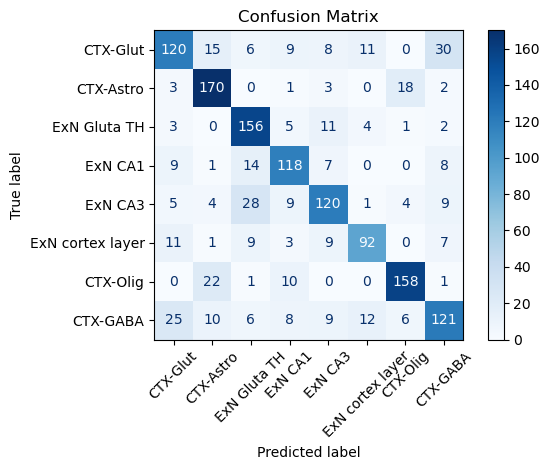

In [28]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# Plot nicely
plt.figure(figsize=(10, 8))
disp.plot(cmap="Blues", values_format="d", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

## Export the loaded model

Writes the model currently in memory to disk in two formats, using the paths from
the Configuration cell:

- **state-dict** (`.pth`) — needs the `DenseNet169(...)` class to reload
- **TorchScript** (`.pt`, "jit") — self-contained; loads with `torch.jit.load` and no model code

Switch `QUAC_CHANNEL` to export a different channel's model.

In [ ]:
# Export the loaded model as state-dict (.pth) and TorchScript (.pt / "jit")
torch.save(model.state_dict(), model_path(CHANNEL))

model_script = torch.jit.script(model)
model_script.save(jit_path(CHANNEL))

print("Saved state-dict :", model_path(CHANNEL))
print("Saved TorchScript:", jit_path(CHANNEL))